In [1]:
import os
import soundfile as sf
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

data_dir = "../DATA/raw" 
manifest_data = []
class_counts = {}

print("Starting Fast-Scan...(Strictly pulling Max 30 files per class) so that i can do as fast as i can.")

for root, dirs, files in os.walk(data_dir):
    # Ignore extra noise folders
    if 'other' in root.lower() or 'background' in root.lower():
        continue
        
    for file in files:
        if file.endswith('.wav') or file.endswith('.WAV'):
            filepath = os.path.join(root, file)
            
            # Extract class name
            rel_path = os.path.relpath(root, data_dir)
            class_label = rel_path.split(os.sep)[0] 
            
            # Initialize tracker for new class
            if class_label not in class_counts:
                class_counts[class_label] = 0
                
            #  EMERGENCY BRAKE: Skip if we already have 30 files for this class!
            if class_counts[class_label] >= 30:
                continue
            
            file_size_mb = os.path.getsize(filepath) / (1024 * 1024)
            
            try:
                info = sf.info(filepath)
                manifest_data.append({
                    "filename": file,
                    "class_label": class_label,
                    "duration_s": round(info.duration, 2),
                    "sr": info.samplerate,
                    "n_channels": info.channels,
                    "file_size_mb": round(file_size_mb, 2),
                    "filepath": filepath
                })
                class_counts[class_label] += 1
                
                # Live Tracking so we ensure that we see something and ensures that the loop was not hang.
                print(f" Loaded: {class_label} -> {file} ({class_counts[class_label]}/30)")
                
            except Exception as e:
                pass

df = pd.DataFrame(manifest_data)

# Saving the manifest
os.makedirs("../DATA/processed", exist_ok=True)
df.to_csv("../DATA/dataset_manifest.csv", index=False)

print("\n" + "="*50)
print(f" BOOM! Manifest Complete! Total files saved: {len(df)}")
print("="*50)

# Quick Distribution check
print(df['class_label'].value_counts())

Starting Fast-Scan...(Strictly pulling Max 30 files per class) so that i can do as fast as i can.
 Loaded: CargoShip -> DATA0145.WAV (1/30)
 Loaded: CargoShip -> DATA0146.WAV (2/30)
 Loaded: CargoShip -> DATA0147.WAV (3/30)
 Loaded: CargoShip -> DATA0148.WAV (4/30)
 Loaded: CargoShip -> DATA0149.WAV (5/30)
 Loaded: CargoShip -> DATA0150.WAV (6/30)
 Loaded: CargoShip -> DATA0151.WAV (7/30)
 Loaded: CargoShip -> DATA0152.WAV (8/30)
 Loaded: CargoShip -> DATA0153.WAV (9/30)
 Loaded: CargoShip -> DATA0154.WAV (10/30)
 Loaded: CargoShip -> DATA0155.WAV (11/30)
 Loaded: CargoShip -> DATA0156.WAV (12/30)
 Loaded: CargoShip -> DATA0157.WAV (13/30)
 Loaded: CargoShip -> DATA0158.WAV (14/30)
 Loaded: CargoShip -> DATA0159.WAV (15/30)
 Loaded: CargoShip -> DATA0160.WAV (16/30)
 Loaded: CargoShip -> DATA0161.WAV (17/30)
 Loaded: CargoShip -> DATA0162.WAV (18/30)
 Loaded: CargoShip -> DATA0163.WAV (19/30)
 Loaded: CargoShip -> DATA0164.WAV (20/30)
 Loaded: KaiYuan -> 20220626105737_M_SpeedBoat_F_W&

In [9]:
import librosa
import librosa.display
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.signal as signal
import warnings
warnings.filterwarnings('ignore')

Starting Exploratory Data Analysis (EDA)


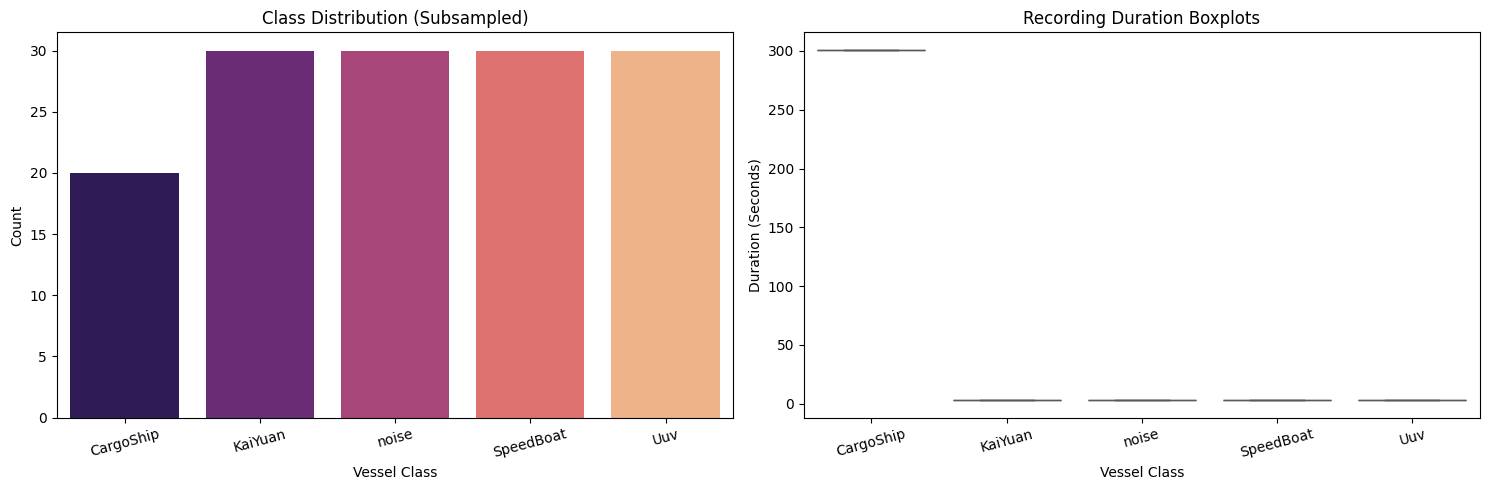

In [11]:
print("Starting Exploratory Data Analysis (EDA)")

# Loading generated manifest
df = pd.read_csv("../DATA/processed/dataset_manifest.csv")
classes = df['class_label'].unique()

# 1. CLASS DISTRIBUTION & DURATION BOXPLOTS

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Histogram
sns.countplot(data=df, x='class_label', palette='magma', ax=axes[0])
axes[0].set_title('Class Distribution (Subsampled)')
axes[0].set_xlabel('Vessel Class')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=15)


# Boxplot
sns.boxplot(data=df, x='class_label', y='duration_s', palette='Set2', ax=axes[1])
axes[1].set_title('Recording Duration Boxplots')
axes[1].set_xlabel('Vessel Class')
axes[1].set_ylabel('Duration (Seconds)')
axes[1].tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.show()

Waveforms & Spectrograms (2 per class)...


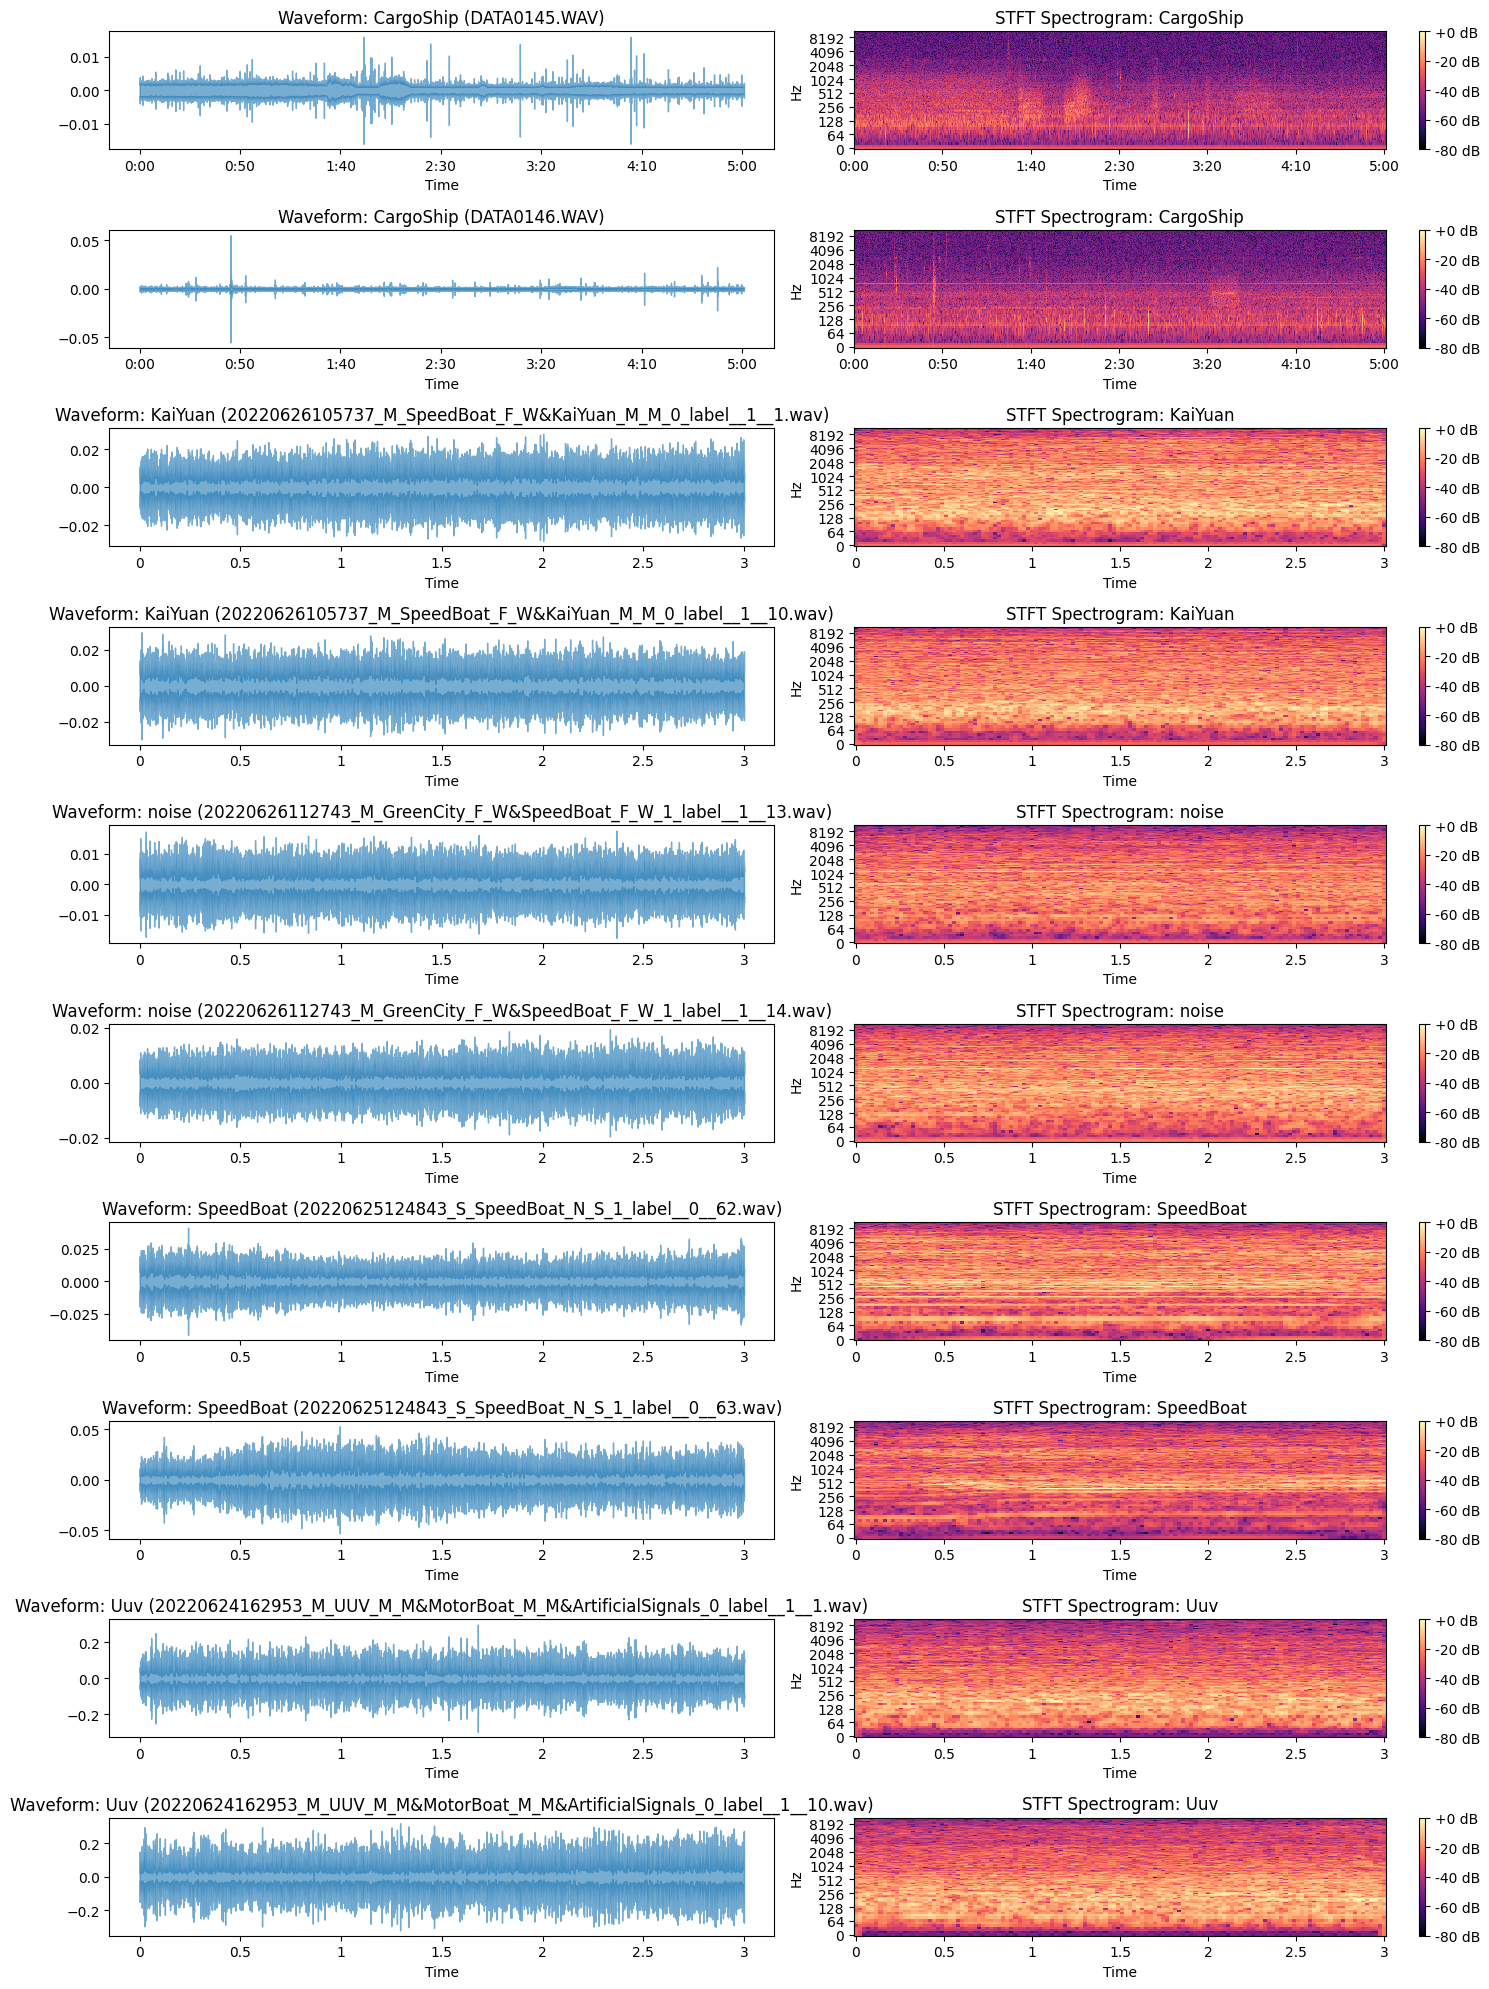

In [13]:
# 2. WAVEFORMS & SPECTROGRAMS (2 per class)

print("Waveforms & Spectrograms (2 per class)...")

# Selecting 2 random files per class
sample_files = df.groupby('class_label').head(2).reset_index(drop=True)
#sample_files = df.groupby('class_label').apply(lambda x: x.sample(2, random_state=42) if len(x) >= 2 else x).reset_index(drop=True)

fig, axes = plt.subplots(nrows=len(classes)*2, ncols=2, figsize=(15, 4 * len(classes)))
row_idx = 0

for _, row in sample_files.iterrows():
    y, sr = librosa.load(row['filepath'], sr=22050, mono=True)
    
    # Plot Waveform
    ax_wave = axes[row_idx, 0]
    librosa.display.waveshow(y, sr=sr, ax=ax_wave, alpha=0.6)
    ax_wave.set_title(f"Waveform: {row['class_label']} ({row['filename']})")
    
    # Short-Time Fourier Transform (in markdown tell about this.)
    # Plot STFT Spectrogram
    D = librosa.amplitude_to_db(np.abs(librosa.stft(y)), ref=np.max)
    ax_spec = axes[row_idx, 1]
    img = librosa.display.specshow(D, sr=sr, x_axis='time', y_axis='log', ax=ax_spec)
    ax_spec.set_title(f"STFT Spectrogram: {row['class_label']}")
    fig.colorbar(img, ax=ax_spec, format="%+2.0f dB")
    
    row_idx += 1

plt.tight_layout()
plt.show()

Calculating Average PSD for all classes (Welch's Method)...


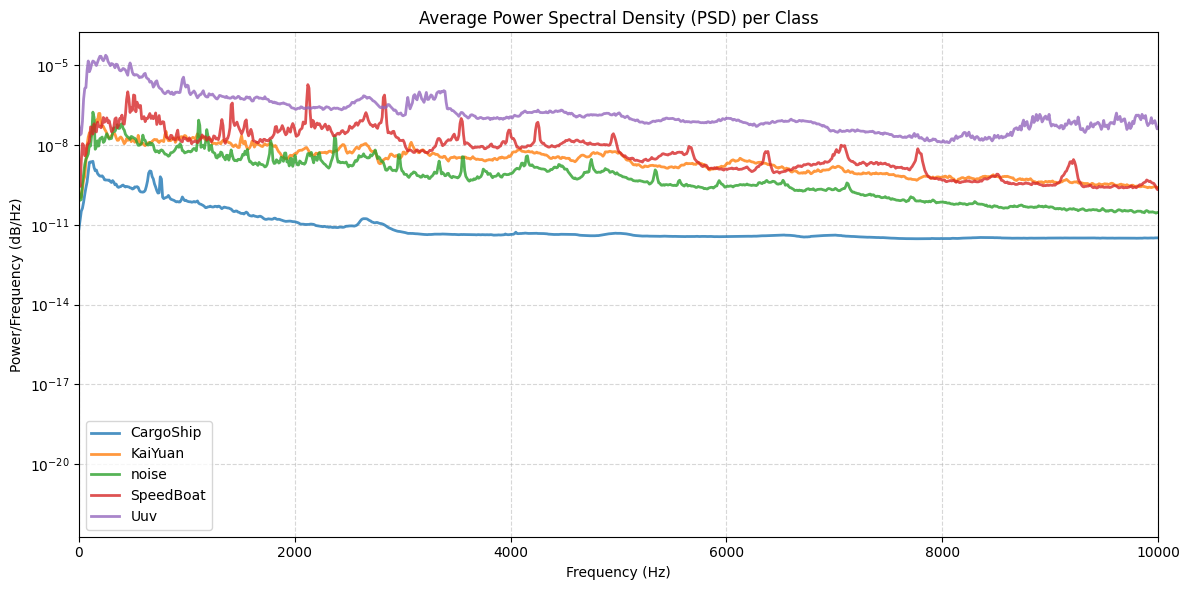

Part 2 completed


In [14]:
# 3. AVERAGE POWER SPECTRAL DENSITY (PSD)

print("Calculating Average PSD for all classes (Welch's Method)...")
plt.figure(figsize=(12, 6))

for cls in classes:
    class_files = df[df['class_label'] == cls]['filepath'].tolist()
    class_psd = []
    
    # Take up to 10 files per class to calculate average PSD quickly
    for filepath in class_files[:10]:
        y, sr = librosa.load(filepath, sr=22050, mono=True)
        freqs, psd = signal.welch(y, sr, nperseg=2048)
        class_psd.append(psd)
        
    avg_psd = np.mean(class_psd, axis=0)
    plt.semilogy(freqs, avg_psd, label=cls, alpha=0.8, linewidth=2)

plt.title('Average Power Spectral Density (PSD) per Class')
plt.xlabel('Frequency (Hz)')
plt.ylabel('Power/Frequency (dB/Hz)')
plt.legend()
plt.grid(True, which="both", ls="--", alpha=0.5)
plt.xlim([0, 10000]) 
plt.tight_layout()
plt.show()

print("Part 2 completed")